**Notebook Criado por:** MSc. Eng. Paulo Silva  
**Notebook Criado em:** 01 / 10 / 2026  
**Última Atualização:** 02 / 10 / 2026

Obs: Este notebook foi desenvolvido sob auxílio de ferramentas de IA.

# **Parede Plana Sem Geração de Calor**

## **Teoria**

Considere a representação da figura a seguir

<div align="center">
    <img src="https://raw.githubusercontent.com/Paulo-de-Souza/HeatTransferPINN/main/Images/aula3/fig_01_parede_plana.svg"
    width="400">
</div>

A equação diferencial do problema 1D é dada por:

$$\frac{d}{dx}\left(k \frac{\partial T}{\partial x}\right) = 0$$

Devemos encontrar a distribuição de temperatura $T(x)$ sendo $k$ igual a uma constante e difente de 0 temos:

$$\frac{\partial^2 T}{\partial x^2} = 0$$

integrando duas vezes em $x$
$$T(x) = c_1 x + c_2$$

para encontrarmos os valores de $c_1$ e $c_2$ devemos olhar as condições de contorno do problema, que na ocasião são
$$x = 0 ⟹ T(0) = T_{s,1}\\ x = L ⟹ T(L) = T_{s,2}$$

fazendo as devidas manipulações e após um certo algebrismo temos que

$$\boxed{T(x) = \left(\frac{ T_{s,2} -T_{s,1} }{L}\right) x  + T_{s,1}} $$

## **Solução Analítica no Python**

Vamos fazer um exemplo em python com as seguintes configurações:

* Comprimento total da parede: $L = 1$ m
* Temperaturas: $T_{s1} = 300 \ K \qquad T_{s2} = 200 \ K$

In [60]:
## Importando Bibliotecas uteis
import numpy as np                  #biblioteca para usar funcoes matematica
import matplotlib.pyplot as plt     #biblioteca para fazer graficos

## Definindo a geometria da parede
L = 1  #[m]

## Definindo as informações do problema
Ts1 = 300  #[K]
Ts2 = 200  #[K]

## Criando os valores de x no intervalo [0, L]
x = np.linspace(0,L,5)  # Usamos a funcao linspace para gerar pontos

## Criando a solucao analitica
Tx = ((Ts2 - Ts1)/L) * x + Ts1

## Imprimindo valores na tela
print(f"Valores de x: {x}")
print(f"Valores de T(x): {Tx}")


Valores de x: [0.   0.25 0.5  0.75 1.  ]
Valores de T(x): [300. 275. 250. 225. 200.]


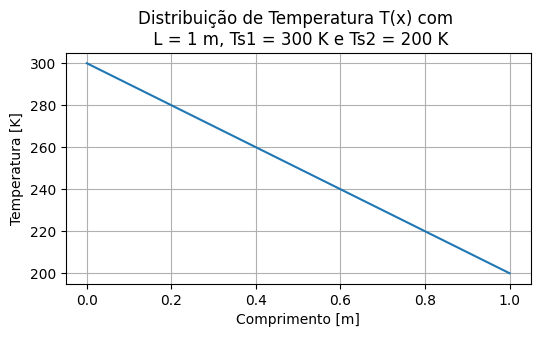

In [61]:
# Criando o grafico da solucao
plt.figure(figsize=(6, 3))
plt.plot(x, Tx, '-')
plt.grid()
plt.ylabel("Temperatura [K]")
plt.xlabel("Comprimento [m]")
plt.title(f"Distribuição de Temperatura T(x) com \n L = {L} m, Ts1 = {Ts1} K e Ts2 = {Ts2} K")
plt.show()


## **Solução Numérica por Diferenças Finitas**

Para obter a solução numérica, o domínio $[0,L]$ é dividido em $N-1$ intervalos igualmente espaçados. Os pontos da malha são definidos por:

$$
x_i = i\Delta x,
\qquad
\Delta x = \frac{L}{N-1}.
$$

A segunda derivada é aproximada pela **diferença central**:

$$
\frac{d^2T}{dx^2}\bigg|_{x_i}
\approx
\frac{T_{i-1}-2T_i+T_{i+1}}{\Delta x^2}.
$$

Como não existe geração interna de calor, a equação discretizada para os pontos internos é:

$$
T_{i-1}-2T_i+T_{i+1}=0.
$$

As temperaturas nas extremidades são impostas diretamente como condições de contorno:

$$
T_0=T_{s,1},
\qquad
T_{N-1}=T_{s,2}.
$$

A aplicação dessas relações gera um sistema linear cuja solução fornece a temperatura nos pontos da malha.

## **Código da Solucao Numérica**

In [63]:
# Parâmetros da malha numérica
N_fd = 5                     # numero de pontos da malha
x_fd = np.linspace(0, L, N_fd) # distribuicao dos pontos na malha
dx_fd = x_fd[1] - x_fd[0]      # espacamento de Delta x

# Matriz e vetor do sistema linear
M_fd = np.zeros((N_fd, N_fd))  # matriz de zeros que sera completada
b_fd = np.zeros(N_fd)          # vetor de zeros que sera completado

# Condição de contorno em x = 0
M_fd[0, 0] = 1
b_fd[0] = Ts1

# Equação nos pontos internos
for i in range(1, N_fd - 1):
    M_fd[i, i - 1] = 1
    M_fd[i, i] = -2
    M_fd[i, i + 1] = 1

# Condição de contorno em x = L
M_fd[-1, -1] = 1
b_fd[-1] = Ts2

# Solução do sistema linear
T_fd = np.linalg.solve(M_fd, b_fd)

# Printando valores na tela
print(f"Matriz A:\n{M_fd}\n")
print(f"Vetor b:\n{b_fd}\n")
print(f"Vetor solucao T:\n{T_fd}")


Matriz A:
[[ 1.  0.  0.  0.  0.]
 [ 1. -2.  1.  0.  0.]
 [ 0.  1. -2.  1.  0.]
 [ 0.  0.  1. -2.  1.]
 [ 0.  0.  0.  0.  1.]]

Vetor b:
[300.   0.   0.   0. 200.]

Vetor solucao T:
[300. 275. 250. 225. 200.]


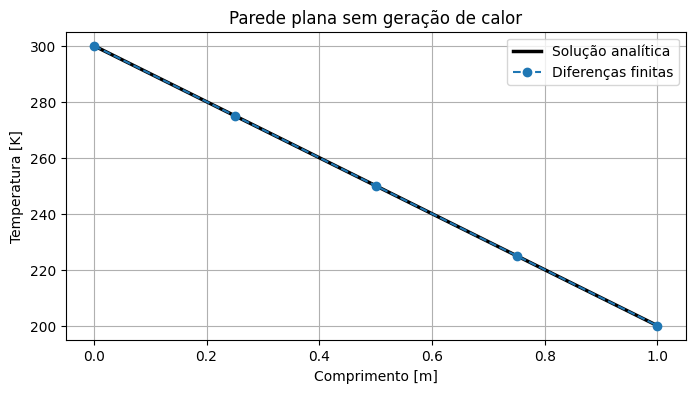

In [64]:
T_analitica_fd = ((Ts2 - Ts1) / L) * x_fd + Ts1
plt.figure(figsize=(8, 4))
plt.plot(x_fd, T_analitica_fd,'k', linewidth=2.5, label="Solução analítica")
plt.plot(x_fd, T_fd, "o--", label="Diferenças finitas")

plt.grid()
plt.xlabel("Comprimento [m]")
plt.ylabel("Temperatura [K]")
plt.title("Parede plana sem geração de calor")
plt.legend()
plt.show()

---

# **Difusao de Calor com Geração de Energia Térmica**

<div align="center">
    <img src="https://raw.githubusercontent.com/Paulo-de-Souza/HeatTransferPINN/main/Images/aula3/fig_01_parede_geracao.png"
    width="400">
</div>


Consdierando a condução de calor unidimensional, em Regime Permanente

$$\frac{\partial}{\partial x}\left(k \frac{\partial T}{\partial x}\right) + \dot{q} = 0$$

sendo $k$ constante e diferente de zero, tem-se:

$$\frac{d^2 T}{dx^2} + \frac{\dot{q}}{k} = 0$$

integrando duas vezes em x chegamos a:
$$T(x) = - \dfrac{\dot{q}x^2}{2k} + c_1 x + c_2$$

Para encontrar os valores de $c_1$ e $c_2$ devemos avaliar as condições de contorno, na ocasião estamos avaliando uma parede de comprimento $2L$ isto é $x \in [-L, L]$

**Em $x = L$**

$$T(L) = T_{s,2} = -\dfrac{\dot{q}L^2}{2k} + c_1 L + c_2 \tag{i}$$

**Em $x = -L$**

$$T(-L) = T_{s,1} = -\dfrac{\dot{q}L^2}{2k} - c_1 L + c_2 \tag{ii}$$

se subtraimos (i) de (ii)

$$T_{s,2} - T_{s,1} = \left[-\dfrac{\dot{q}L^2}{2k} + c_1 L + c_2 \right] - \left[-\dfrac{\dot{q}L^2}{2k} - c_1 L + c_2 \right]$$

isso implica então
$$c_1 = \frac{T_{s,2} - T_{s,1} }{2L}$$

se somarmos (i) e (ii) chegaremos a
$$c_2 = \dfrac{\dot{q}L^2}{2k} + \frac{T_{s,2} + T_{s,1} }{2}$$

portanto a distribuição de temperatura é dada por:

$$\boxed{T(x) = \dfrac{\dot{q}L^2}{2k} \left(1 - \frac{x^2}{L^2} \right) + \frac{T_{s,2} - T_{s,1} }{2L} x + \frac{T_{s,2} + T_{s,1} }{2} }$$

## **Solucao Analitica e Gráfico no Python**

Vamos fazer um exemplo em python com as seguintes configurações:

* Comprimento total da parede: $L = 0.5$ m
* Temperaturas iguais: $T_{s1} = T_{s2} = 300 \ K$
* Geração de calor: $\dot{q} = 1.5 \times 10^6 \ W/m^3$
* Condutividade Térmica: $k = 150 \ W/mK$

Queremos:

* Plotar a figura completa da solução
* Destacar o ponto de máximo (nesse caso em $x=0$)

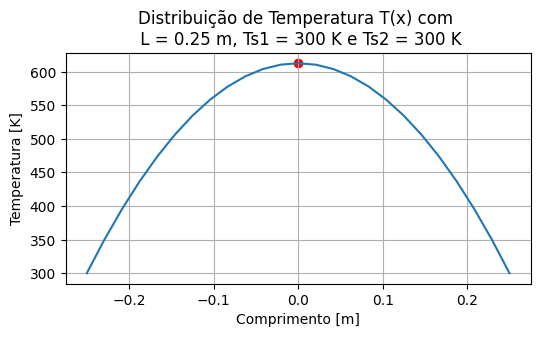

In [65]:
## Importando Bibliotecas uteis
import numpy as np                  #biblioteca para usar funcoes matematica
import matplotlib.pyplot as plt     #biblioteca para fazer graficos

## Definindo a geometria da parede
Lc = 0.5     #[m] comprimento total da parede
L = Lc/2     #[m] meia parede

## Definindo as informações do problema
Ts1 = 300  #[K]
Ts2 = 300  #[K]
q_dot = 1.5e6 #[W/m^3]
k = 150 #[W/m K]

## Criando os valores de x no intervalo [-L, L]
x = np.linspace(-L,L, 25)  # Usamos a funcao linspace para gerar pontos

## Criando a solucao analitica por partes
def T_geracao(x, Ts1, Ts2, q_dot = 1.5e6, k = 150):
  T_p0 = (Ts2 + Ts1)/2
  T_p1 = ((Ts2 - Ts1)/(2*L)) * x
  T_p2 = ((q_dot * L**2) / (2*k)) * (1 - (x/L)**2)
  Tx = T_p2 + T_p1 + T_p0
  return Tx

Tx = T_geracao(x, Ts1, Ts2, q_dot = 1.5e6, k = 150)

## Formula para o ponto maximo quando Ts1 = Ts2, solucao em x = 0
Tx0 = T_geracao(0, Ts1, Ts2, q_dot = 1.5e6, k = 150)

# Criando o grafico da solucao
plt.figure(figsize=(6, 3))
plt.plot(x, Tx, '-')             # plotando a curva completa
plt.scatter(0, Tx0, c = 'red')   # plotando o ponto maximo
plt.grid()
plt.ylabel("Temperatura [K]")
plt.xlabel("Comprimento [m]")
plt.title(f"Distribuição de Temperatura T(x) com \n L = {L} m, Ts1 = {Ts1} K e Ts2 = {Ts2} K")
plt.show()


## **Solução Numérica por Diferenças Finitas**

Neste caso, o domínio da parede é $[-L,L]$ e existe uma geração volumétrica uniforme de energia térmica.

A equação diferencial é:

$$
\frac{d^2T}{dx^2}+\frac{\dot{q}}{k}=0.
$$

Aplicando a **diferença central** à segunda derivada:

$$
\frac{T_{i-1}-2T_i+T_{i+1}}{\Delta x^2} +\frac{\dot{q}}{k}=0.
$$

Reorganizando a expressão, obtemos:

$$
T_{i-1}-2T_i+T_{i+1} = -\frac{\dot{q}}{k}\Delta x^2.
$$

O termo de geração térmica aparece no vetor do sistema linear. As temperaturas nas extremidades continuam sendo impostas diretamente:

$$T(-L)=T_{s,1}, \qquad T(L)=T_{s,2}.$$

### **Código: solução numérica**

In [66]:
# Parâmetros da malha numérica
N_fd_2 = 11
x_fd_2 = np.linspace(-L, L, N_fd_2)
dx_fd_2 = x_fd_2[1] - x_fd_2[0]

# Matriz e vetor do sistema linear
M_fd_2 = np.zeros((N_fd_2, N_fd_2))
b_fd_2 = np.zeros(N_fd_2)

# Condição de contorno em x = -L
M_fd_2[0, 0] = 1
b_fd_2[0] = Ts1

# Equação nos pontos internos
for i in range(1, N_fd_2 - 1):
    M_fd_2[i, i - 1] = 1
    M_fd_2[i, i] = -2
    M_fd_2[i, i + 1] = 1
    b_fd_2[i] = -(q_dot / k) * dx_fd_2**2

# Condição de contorno em x = L
M_fd_2[-1, -1] = 1
b_fd_2[-1] = Ts2

# Solução do sistema linear
T_fd_2 = np.linalg.solve(M_fd_2, b_fd_2)

# print(f"Valores de x da malha: {x_fd_2}")
# print(f"Valores numéricos de T(x): {T_fd_2}")

**Código: comparação entre as soluções**

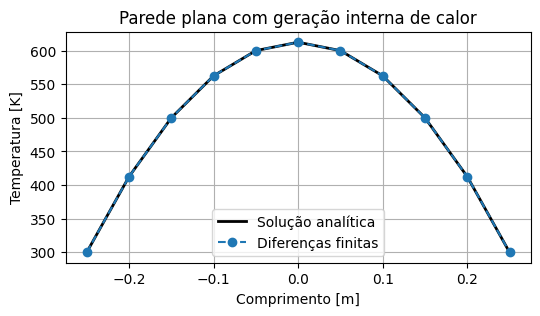

In [67]:
T_analitica_fd_2 = (
    ((q_dot * L**2) / (2 * k)) * (1 - (x_fd_2 / L)**2)
    + ((Ts2 - Ts1) / (2 * L)) * x_fd_2
    + ((Ts2 + Ts1) / 2)
)

plt.figure(figsize=(6, 3))
plt.plot(x_fd_2, T_analitica_fd_2, 'k', linewidth=2, label="Solução analítica")
plt.plot(x_fd_2, T_fd_2, "o--", label="Diferenças finitas")

plt.grid()
plt.xlabel("Comprimento [m]")
plt.ylabel("Temperatura [K]")
plt.title("Parede plana com geração interna de calor")
plt.legend()
plt.show()

# **Parede plana composta por dois materiais**

<div align=center>
    <img src="https://raw.githubusercontent.com/Paulo-de-Souza/HeatTransferPINN/main/Images/aula3/aula3_pt1_ex3.png" width = 500>
</div>

Consideramos uma parede plana composta por dois materiais diferentes, A e B, submetida à geração interna de energia térmica no material A.

As propriedades do problema são:

- Material A:

$$
L_A=50\,\mathrm{mm},
\qquad
k_A=75\,\mathrm{W/(mK)}
$$

- Material B:

$$
L_B=20\,\mathrm{mm},
\qquad
k_B=150\,\mathrm{W/(mK)}
$$

- Geração volumétrica no material A:

$$
\dot{q}=1{,}5\times10^6\,\mathrm{W/m^3}
$$

- Temperatura do fluido externo:

$$
T_\infty=30^\circ\mathrm{C}
$$

- Coeficiente convectivo:

$$
h_\infty=1000\,\mathrm{W/(m^2K)}
$$

O lado esquerdo da parede é adiabático. A superfície direita do material B troca calor por convecção com o fluido externo.

A temperatura e o fluxo de calor são contínuos na interface entre os materiais.

## **Solução Analítica**

A taxa de calor gerada no material A por unidade de área é:

$$q''=\dot{q}L_A.$$

Como o lado esquerdo é adiabático, todo o calor gerado no material A atravessa o material B e é transferido por convecção na superfície direita.

A temperatura da superfície externa é obtida por:

$$T_2=T_\infty+\frac{q''}{h_\infty}.$$

A temperatura na interface entre os materiais é:

$$
T_1=T_2+\frac{q''L_B}{k_B}.
$$

A temperatura máxima ocorre no lado adiabático do material A:

$$T_0=T_1+\frac{\dot{q}L_A^2}{2k_A}.$$

Para o material A:

$$T_A(x)=T_0-\frac{\dot{q}x^2}{2k_A},\qquad 0\leq x\leq L_A.$$

Para o material B:

$$T_B(x)=T_1-\frac{q''}{k_B}(x-L_A), \qquad L_A\leq x\leq L_A+L_B.
$$

In [ ]:
# Propriedades geométricas e térmicas
LA = 50e-3       # Espessura do material A [m]
LB = 20e-3       # Espessura do material B [m]
L_total = LA + LB

kA = 75          # Condutividade do material A [W/(m K)]
kB = 150         # Condutividade do material B [W/(m K)]

q_dot_3 = 1.5e6  # Geração volumétrica no material A [W/m^3]

T_inf = 30        # Temperatura do fluido [°C]
h_inf = 1000      # Coeficiente convectivo [W/(m^2 K)]

# Malha para representar a solução analítica
x_3 = np.linspace(0, L_total, 400)

# Fluxo total gerado no material A
q_flux_3 = q_dot_3 * LA

# Temperaturas características
T2_3 = T_inf + q_flux_3 / h_inf
T1_3 = T2_3 + q_flux_3 * LB / kB
T0_3 = T1_3 + q_dot_3 * LA**2 / (2 * kA)

# Distribuição analítica de temperatura
T_analitica_3 = np.where(
    x_3 <= LA,
    T0_3 - q_dot_3 * x_3**2 / (2 * kA),
    T1_3 - q_flux_3 * (x_3 - LA) / kB
)

print(f"Temperatura máxima T0: {T0_3:.2f} °C")
print(f"Temperatura na interface T1: {T1_3:.2f} °C")
print(f"Temperatura superficial T2: {T2_3:.2f} °C")

Temperatura máxima T0: 140.00 °C
Temperatura na interface T1: 115.00 °C
Temperatura superficial T2: 105.00 °C


## **Grafico da solucao analitica**

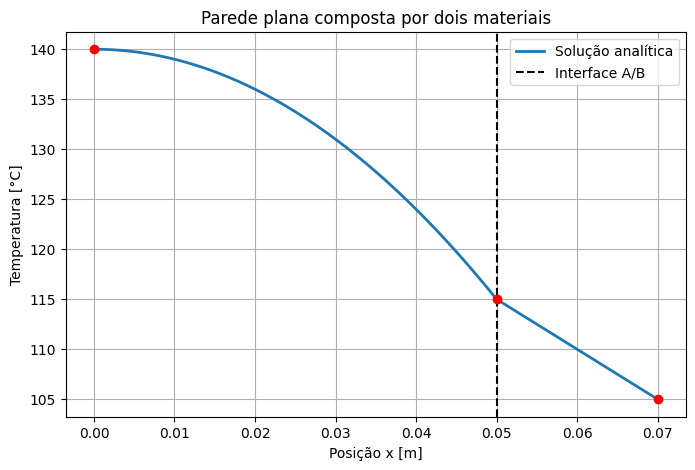

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    x_3,
    T_analitica_3,
    linewidth=2,
    label="Solução analítica"
)

plt.axvline(
    LA,
    color="black",
    linestyle="--",
    label="Interface A/B"
)

plt.scatter(
    [0, LA, L_total],
    [T0_3, T1_3, T2_3],
    color="red",
    zorder=3
)

plt.grid()
plt.xlabel("Posição x [m]")
plt.ylabel("Temperatura [°C]")
plt.title("Parede plana composta por dois materiais")
plt.legend()
plt.show()

## **EXTRA: Solução Numérica por Diferenças Finitas**

Como a condutividade térmica muda na interface entre os materiais, a equação deve ser discretizada em sua forma conservativa:

$$
\frac{d}{dx}\left(k\frac{dT}{dx}\right) +\dot{q}=0.
$$

Para um ponto interno da malha, utiliza-se:

$$
\frac{1}{\Delta x} \left[k_{i+\frac{1}{2}} \frac{T_{i+1}-T_i}{\Delta x} - k_{i-\frac{1}{2}} \frac{T_i-T_{i-1}}{\Delta x} \right] +\dot{q}_i=0.
$$

As condutividades nas faces dependem do material existente em cada região. A geração volumétrica é considerada apenas nos pontos pertencentes ao material A.

No lado esquerdo, aplica-se a condição adiabática:

$$
\frac{dT}{dx}\bigg|_{x=0}=0.
$$

No lado direito, aplica-se a condição convectiva:

$$
-k_B\frac{dT}{dx}\bigg|_{x=L_A+L_B}
= h_\infty \left[T(L_A+L_B)-T_\infty \right].
$$

Essa formulação garante a continuidade do fluxo de calor na interface entre os materiais.

In [ ]:
# Propriedades geométricas e térmicas
LA = 50e-3       # Espessura do material A [m]
LB = 20e-3       # Espessura do material B [m]
L_total = LA + LB

kA = 75          # Condutividade do material A [W/(m K)]
kB = 150         # Condutividade do material B [W/(m K)]

q_dot_3 = 1.5e6  # Geração volumétrica no material A [W/m^3]

T_inf = 30        # Temperatura do fluido [°C]
h_inf = 1000      # Coeficiente convectivo [W/(m^2 K)]

# Número de pontos da malha
N_fd_3 = 501

x_fd_3 = np.linspace(0, L_total, N_fd_3)
dx_fd_3 = x_fd_3[1] - x_fd_3[0]

# Índice aproximado da interface
i_interface = np.argmin(np.abs(x_fd_3 - LA))

# Condutividade nas faces da malha
x_faces_3 = 0.5 * (x_fd_3[:-1] + x_fd_3[1:])

k_faces_3 = np.where(
    x_faces_3 < LA,
    kA,
    kB
)

# Geração volumétrica em cada ponto
q_nodes_3 = np.where(
    x_fd_3 < LA,
    q_dot_3,
    0.0
)

# Matriz e vetor do sistema linear
M_fd_3 = np.zeros((N_fd_3, N_fd_3))
b_fd_3 = np.zeros(N_fd_3)

# Condição adiabática no lado esquerdo:
# dT/dx = 0
M_fd_3[0, 0] = -1
M_fd_3[0, 1] = 1
b_fd_3[0] = 0

# Equações nos pontos internos
for i in range(1, N_fd_3 - 1):
    k_left = k_faces_3[i - 1]
    k_right = k_faces_3[i]

    M_fd_3[i, i - 1] = k_left
    M_fd_3[i, i] = -(k_left + k_right)
    M_fd_3[i, i + 1] = k_right

    b_fd_3[i] = -q_nodes_3[i] * dx_fd_3**2

# Condição convectiva no lado direito:
# -kB dT/dx = h_inf (T - T_inf)
M_fd_3[-1, -2] = -kB / dx_fd_3
M_fd_3[-1, -1] = kB / dx_fd_3 + h_inf
b_fd_3[-1] = h_inf * T_inf

# Solução numérica
T_fd_3 = np.linalg.solve(M_fd_3, b_fd_3)

print(f"Temperatura numérica máxima: {T_fd_3.max():.2f} °C")
print(f"Temperatura numérica na interface: {T_fd_3[i_interface]:.2f} °C")
print(f"Temperatura numérica na superfície: {T_fd_3[-1]:.2f} °C")

Temperatura numérica máxima: 139.89 °C
Temperatura numérica na interface: 114.98 °C
Temperatura numérica na superfície: 104.97 °C


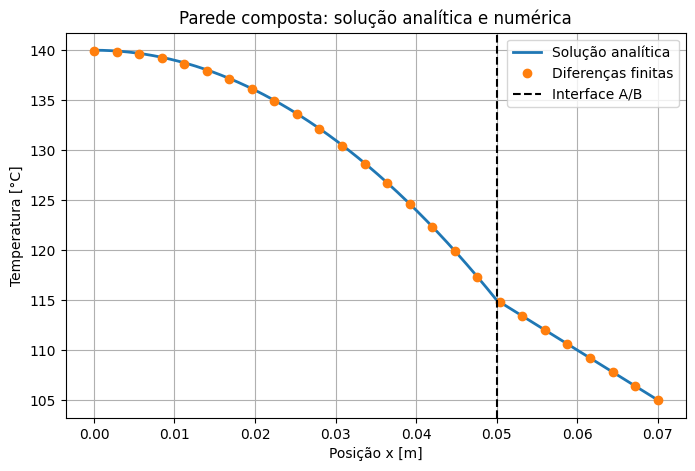

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    x_3,
    T_analitica_3,
    linewidth=2,
    label="Solução analítica"
)

plt.plot(
    x_fd_3,
    T_fd_3,
    "o",
    markevery=20,
    label="Diferenças finitas"
)

plt.axvline(
    LA,
    color="black",
    linestyle="--",
    label="Interface A/B"
)

plt.grid()
plt.xlabel("Posição x [m]")
plt.ylabel("Temperatura [°C]")
plt.title("Parede composta: solução analítica e numérica")
plt.legend()
plt.show()